In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# Read npz file from folder

import numpy as np

motor_data = np.load('MOTOR_ALL_RESULTS.npz')

# List all arrays stored in the archive
print(motor_data.files)

['name', 'ALL_RESULTS']


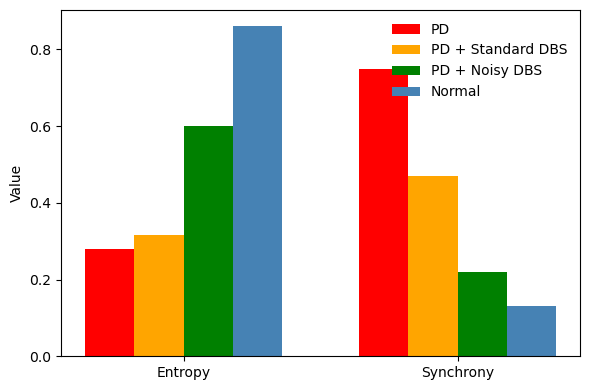

In [28]:
STN_GPE_entropy = {'Normal':0.86,
                   'PD':0.279,
                   'PD_std_DBS':0.315,
                   'PD_noisy_DBS':0.6}

STN_GPE_synchrony = {'Normal':0.13,
                   'PD':0.75,
                   'PD_std_DBS': 0.47,
                   'PD_noisy_DBS': 0.22}


x = np.arange(2)  # Entropy, Synchrony
width = 0.18

fifig, ax = plt.subplots(figsize=(6, 4))

ax.bar(x - 1.5*width,
       [STN_GPE_entropy['PD'], STN_GPE_synchrony['PD']],
       width,
       label='PD',
       color='red')

ax.bar(x - 0.5*width,
       [STN_GPE_entropy['PD_std_DBS'], STN_GPE_synchrony['PD_std_DBS']],
       width,
       label='PD + Standard DBS',
       color='orange')

ax.bar(x + 0.5*width,
       [STN_GPE_entropy['PD_noisy_DBS'], STN_GPE_synchrony['PD_noisy_DBS']],
       width,
       label='PD + Noisy DBS',
       color='green')

ax.bar(x + 1.5*width,
       [STN_GPE_entropy['Normal'], STN_GPE_synchrony['Normal']],
       width,
       label='Normal',
       color='steelblue')

ax.set_xticks(x)
ax.set_xticklabels(['Entropy', 'Synchrony'])
ax.set_ylabel('Value')

ax.legend(frameon=False, ncol=1, loc = 'upper right')


plt.tight_layout()
plt.show()

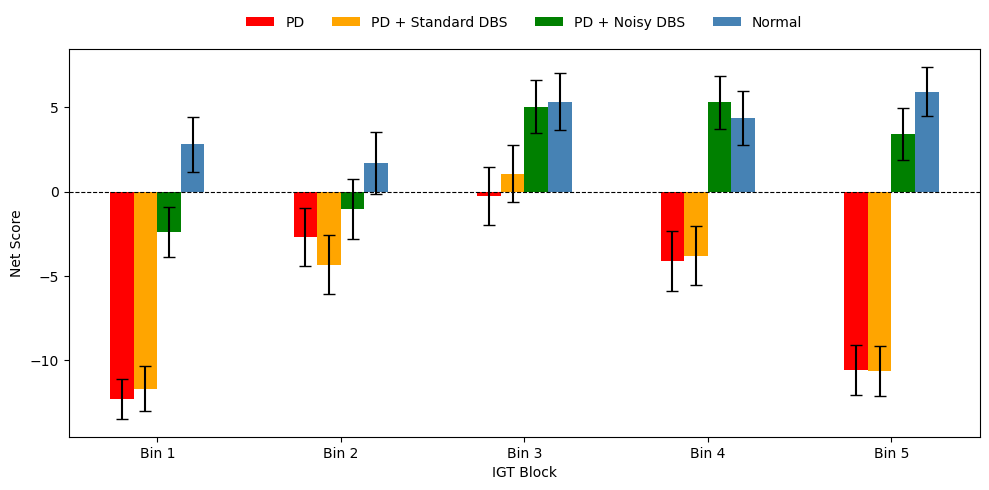

In [18]:
IGT_PD_Noisy_DBS = [-2.38, -1.04, 5.04, 5.30, 3.44]
IGT_PD_Noisy_DBS_std = [1.49, 1.77, 1.58, 1.57, 1.54]

IGT_PD = [-12.28, -2.7, -0.28, -4.12, -10.58]
IGT_PD_std = [1.2, 1.72, 1.72, 1.77, 1.5]

IGT_PD_std_DBS = [-11.68, -4.32, 1.06, -3.8, -10.64]
IGT_PD_std_DBS_std = [1.32, 1.75, 1.68, 1.74, 1.49]

IGT_Normal = [2.8, 1.7, 5.32, 4.38, 5.92]
IGT_Normal_std = [1.64, 1.84, 1.68, 1.6, 1.47]


bins = np.arange(5)

# Larger gap between groups
group_spacing = 1.4
x = np.arange(len(bins)) * group_spacing

width = 0.18

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - 1.5*width, IGT_PD, width,
       yerr=IGT_PD_std, capsize=4,
       label='PD', color = 'red')

ax.bar(x - 0.5*width, IGT_PD_std_DBS, width,
       yerr=IGT_PD_std_DBS_std, capsize=4,
       label='PD + Standard DBS', color = 'orange')

ax.bar(x + 0.5*width, IGT_PD_Noisy_DBS, width,
       yerr=IGT_PD_Noisy_DBS_std, capsize=4,
       label='PD + Noisy DBS', color = 'green')

ax.bar(x + 1.5*width, IGT_Normal, width,
       yerr=IGT_Normal_std, capsize=4,
       label='Normal', color = 'steelblue')

ax.set_xticks(x)
ax.set_xticklabels([f'Bin {i}' for i in range(1, 6)])

ax.set_xlabel('IGT Block')
ax.set_ylabel('Net Score')
ax.axhline(0, color='k', linestyle='--', linewidth=0.8)

ax.legend(frameon=False, ncol=4, loc='upper center',
          bbox_to_anchor=(0.5, 1.12))

plt.tight_layout()
plt.show()

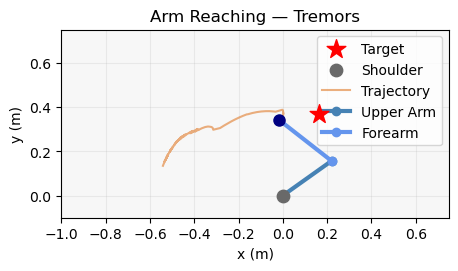

In [29]:
import pickle
import matplotlib.pyplot as plt

# Load
with open('PD_traj_data.pkl', 'rb') as f:
    data = pickle.load(f)

name = data['condition']
X_t = data['target']
traj = data['trajectory']
shoulders = data['shoulders']
elbows = data['elbows']
hands = data['hands']
colour = data['colour']

# Last frame
fi = len(traj) - 1

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ax.set_xlim(-1, 0.75)
ax.set_ylim(-0.10, 0.75)
ax.set_aspect('equal')
ax.set_facecolor('#f7f7f7')
ax.grid(alpha=0.2)

# Target and shoulder
ax.scatter(*X_t, s=200, color='red', marker='*', zorder=6, label='Target')
ax.scatter(0, 0, s=80, color='dimgray', zorder=7, label='Shoulder')

# Full trajectory
ax.plot(
    traj[:, 0],
    traj[:, 1],
    color=colour,
    lw=1.5,
    alpha=0.6,
    label='Trajectory'
)

# Upper arm
ax.plot(
    [shoulders[fi, 0], elbows[fi, 0]],
    [shoulders[fi, 1], elbows[fi, 1]],
    '-o',
    lw=3,
    ms=6,
    color='steelblue',
    label='Upper Arm'
)

# Forearm
ax.plot(
    [elbows[fi, 0], hands[fi, 0]],
    [elbows[fi, 1], hands[fi, 1]],
    '-o',
    lw=3,
    ms=6,
    color='cornflowerblue',
    label='Forearm'
)

# Hand
ax.plot(
    hands[fi, 0],
    hands[fi, 1],
    'o',
    ms=8,
    color='navy'
)

ax.set_title(f'Arm Reaching — {name}')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
ax.legend()

plt.show()

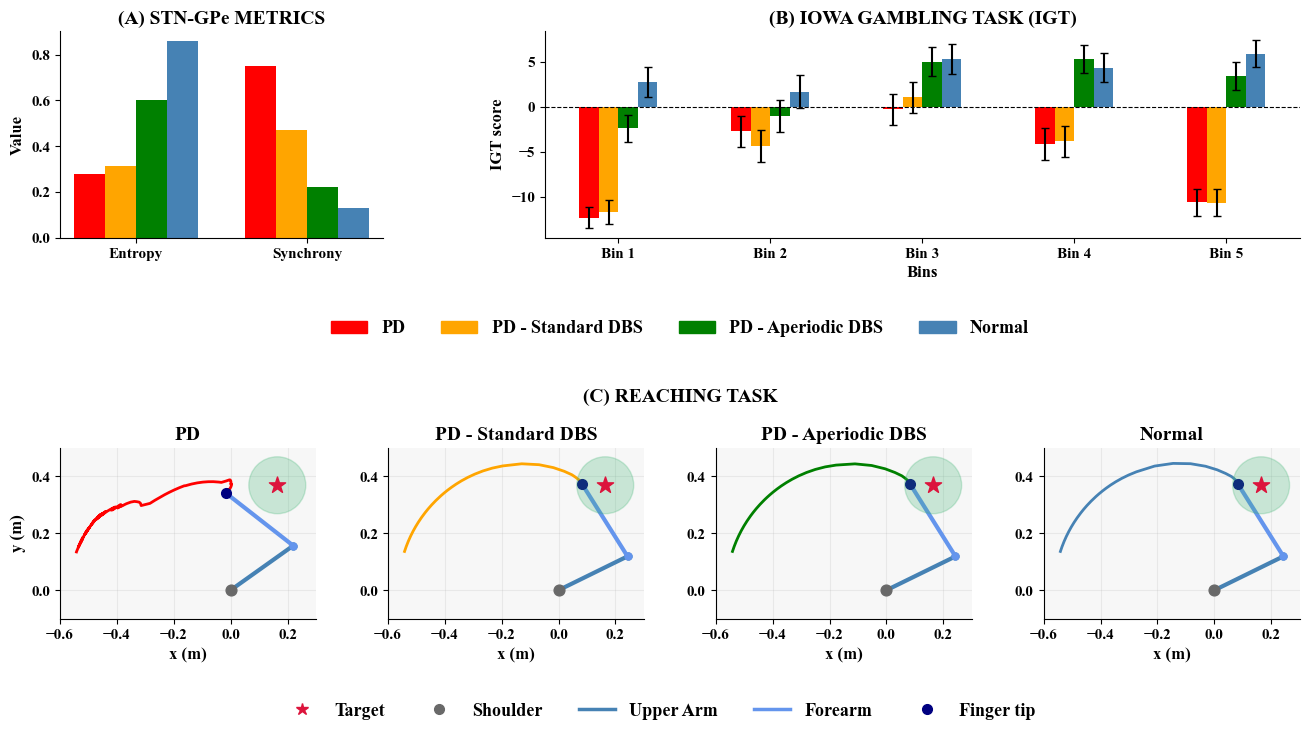

In [31]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from matplotlib.lines import Line2D

# ── Font sizes ────────────────────────────────────────────────────────────────
TITLE_SIZE  = 14
LABEL_SIZE  = 12
TICK_SIZE   = 11
LEGEND_SIZE = 13

rcParams['font.family']      = 'Times New Roman'
rcParams['font.weight']      = 'bold'
rcParams['axes.titlesize']   = TITLE_SIZE
rcParams['axes.titleweight'] = 'bold'
rcParams['axes.labelsize']   = LABEL_SIZE
rcParams['axes.labelweight'] = 'bold'
rcParams['xtick.labelsize']  = TICK_SIZE
rcParams['ytick.labelsize']  = TICK_SIZE

# ── Colors & labels ───────────────────────────────────────────────────────────
COLORS = {
    'PD':          'red',
    'PD_std_DBS':  'orange',
    'PD_noisy_DBS':'green',
    'Normal':      'steelblue',
}
LABELS = {
    'PD':          'PD',
    'PD_std_DBS':  'PD - Standard DBS',
    'PD_noisy_DBS':'PD - Aperiodic DBS',
    'Normal':      'Normal',
}
CONDITIONS = ['PD', 'PD_std_DBS', 'PD_noisy_DBS', 'Normal']

TRAJ_FILES = {
    'PD':          'PD_traj_data.pkl',
    'PD_std_DBS':  'PD_std_DBS_traj_data.pkl',
    'PD_noisy_DBS':'PD_Noisy_DBS_traj_data.pkl',
    'Normal':      'Normal_traj_data.pkl',
}

# ── Data ──────────────────────────────────────────────────────────────────────
STN_GPE_entropy   = {'Normal':0.86,  'PD':0.279, 'PD_std_DBS':0.315, 'PD_noisy_DBS':0.6}
STN_GPE_synchrony = {'Normal':0.13,  'PD':0.75,  'PD_std_DBS':0.47,  'PD_noisy_DBS':0.22}

IGT = {
    'PD':          {'mean':[-12.28,-2.7,-0.28,-4.12,-10.58], 'std':[1.2, 1.72,1.72,1.77,1.5]},
    'PD_std_DBS':  {'mean':[-11.68,-4.32,1.06,-3.8,-10.64],  'std':[1.32,1.75,1.68,1.74,1.49]},
    'PD_noisy_DBS':{'mean':[-2.38,-1.04,5.04,5.30,3.44],     'std':[1.49,1.77,1.58,1.57,1.54]},
    'Normal':      {'mean':[2.8,1.7,5.32,4.38,5.92],         'std':[1.64,1.84,1.68,1.6,1.47]},
}

# ── Layout: 3-row outer grid — plots | legend strip | traj ───────────────────
fig = plt.figure(figsize=(16, 8))
outer = gridspec.GridSpec(3, 1, figure=fig,
                          height_ratios=[1, 0.08, 1.1],
                          hspace=0.55)

top_row  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0],
                                            wspace=0.3, width_ratios=[0.3, 0.7])
traj_row = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[2], wspace=0.28)

# ─── (A) STN-GPe ──────────────────────────────────────────────────────────────
ax_stn = fig.add_subplot(top_row[0])
x, width = np.arange(2), 0.18

for i, cond in enumerate(CONDITIONS):
    vals = [STN_GPE_entropy[cond], STN_GPE_synchrony[cond]]
    ax_stn.bar(x + (i - 1.5)*width, vals, width,
               color=COLORS[cond], label=LABELS[cond])

ax_stn.set_xticks(x)
ax_stn.set_xticklabels(['Entropy', 'Synchrony'])
ax_stn.set_ylabel('Value')
ax_stn.set_title('(A) STN-GPe METRICS')
ax_stn.spines['top'].set_visible(False)
ax_stn.spines['right'].set_visible(False)

# ─── (B) IGT ──────────────────────────────────────────────────────────────────
ax_igt = fig.add_subplot(top_row[1])
x_igt  = np.arange(5) * 1.4

for i, cond in enumerate(CONDITIONS):
    ax_igt.bar(x_igt + (i - 1.5)*width,
               IGT[cond]['mean'], width,
               yerr=IGT[cond]['std'], capsize=3,
               color=COLORS[cond], label=LABELS[cond])

ax_igt.set_xticks(x_igt)
ax_igt.set_xticklabels([f'Bin {i}' for i in range(1, 6)])
ax_igt.set_xlabel('Bins')
ax_igt.set_ylabel('IGT score')
ax_igt.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_igt.set_title('(B) IOWA GAMBLING TASK (IGT)')
ax_igt.spines['top'].set_visible(False)
ax_igt.spines['right'].set_visible(False)

# ─── Condition legend — dedicated invisible axis in middle strip ───────────────
ax_leg = fig.add_subplot(outer[1])
ax_leg.set_axis_off()

cond_handles = [
    plt.Rectangle((0,0), 1, 1, color=COLORS[c], label=LABELS[c])
    for c in CONDITIONS
]
ax_leg.legend(
    handles=cond_handles,
    loc='center',
    ncol=4,
    frameon=False,
    prop={'family':'Times New Roman', 'weight':'bold', 'size':LEGEND_SIZE}
)

# ─── (C) Motor Reaching — invisible spanning axis for shared title ─────────────
ax_title = fig.add_subplot(outer[2])
ax_title.set_axis_off()
ax_title.set_title('(C) REACHING TASK', fontsize=TITLE_SIZE,
                   fontweight='bold', pad=12, y=1.01)

# ─── 4 trajectory subplots ────────────────────────────────────────────────────
for idx, cond in enumerate(CONDITIONS):
    ax = fig.add_subplot(traj_row[idx])

    with open(TRAJ_FILES[cond], 'rb') as f:
        d = pickle.load(f)

    X_t       = d['target']
    traj      = d['trajectory']
    shoulders = d['shoulders']
    elbows    = d['elbows']
    hands     = d['hands']
    fi        = len(traj) - 1

    ax.set_xlim(-0.6, 0.3)
    ax.set_ylim(-0.10, 0.5)
    ax.set_aspect('equal')
    ax.set_facecolor('#f7f7f7')
    ax.grid(alpha=0.2)

    ax.scatter(*X_t, s=150, color='crimson', marker='*', zorder=6)
    ax.scatter(0, 0,  s=60,  color='dimgray',            zorder=7)
    ax.plot(traj[:, 0], traj[:, 1], color=COLORS[cond], lw=2, alpha=1.0)
    ax.plot([shoulders[fi,0], elbows[fi,0]],
            [shoulders[fi,1], elbows[fi,1]],
            '-o', lw=3, ms=5, color='steelblue')
    ax.plot([elbows[fi,0], hands[fi,0]],
            [elbows[fi,1], hands[fi,1]],
            '-o', lw=3, ms=5, color='cornflowerblue')
    ax.plot(hands[fi,0], hands[fi,1], 'o', ms=7, color='navy')
    ax.add_patch(plt.Circle(X_t, radius=0.1, color='mediumseagreen', alpha=0.25, zorder=5))
    ax.set_title(LABELS[cond])
    ax.set_xlabel('x (m)')
    if idx == 0:
        ax.set_ylabel('y (m)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ─── Anatomy legend — second dedicated invisible axis below traj ───────────────
ax_leg2 = fig.add_axes([0.15, 0.01, 0.7, 0.04])   # [left, bottom, width, height]
ax_leg2.set_axis_off()

traj_handles = [
    Line2D([0],[0], color='crimson',       marker='*', linestyle='None', ms=9,  label='Target'),
    Line2D([0],[0], color='dimgray',        marker='o', linestyle='None', ms=7,  label='Shoulder'),
    Line2D([0],[0], color='steelblue',      lw=2.5,                             label='Upper Arm'),
    Line2D([0],[0], color='cornflowerblue', lw=2.5,                             label='Forearm'),
    Line2D([0],[0], color='navy',        marker='o', linestyle='None', ms=7,  label='Finger tip'),
]
ax_leg2.legend(
    handles=traj_handles,
    loc='center',
    ncol=5,
    frameon=False,
    prop={'family':'Times New Roman', 'weight':'bold', 'size':LEGEND_SIZE}
)

plt.savefig('combined_plot.png', dpi=300, bbox_inches='tight')
plt.show()

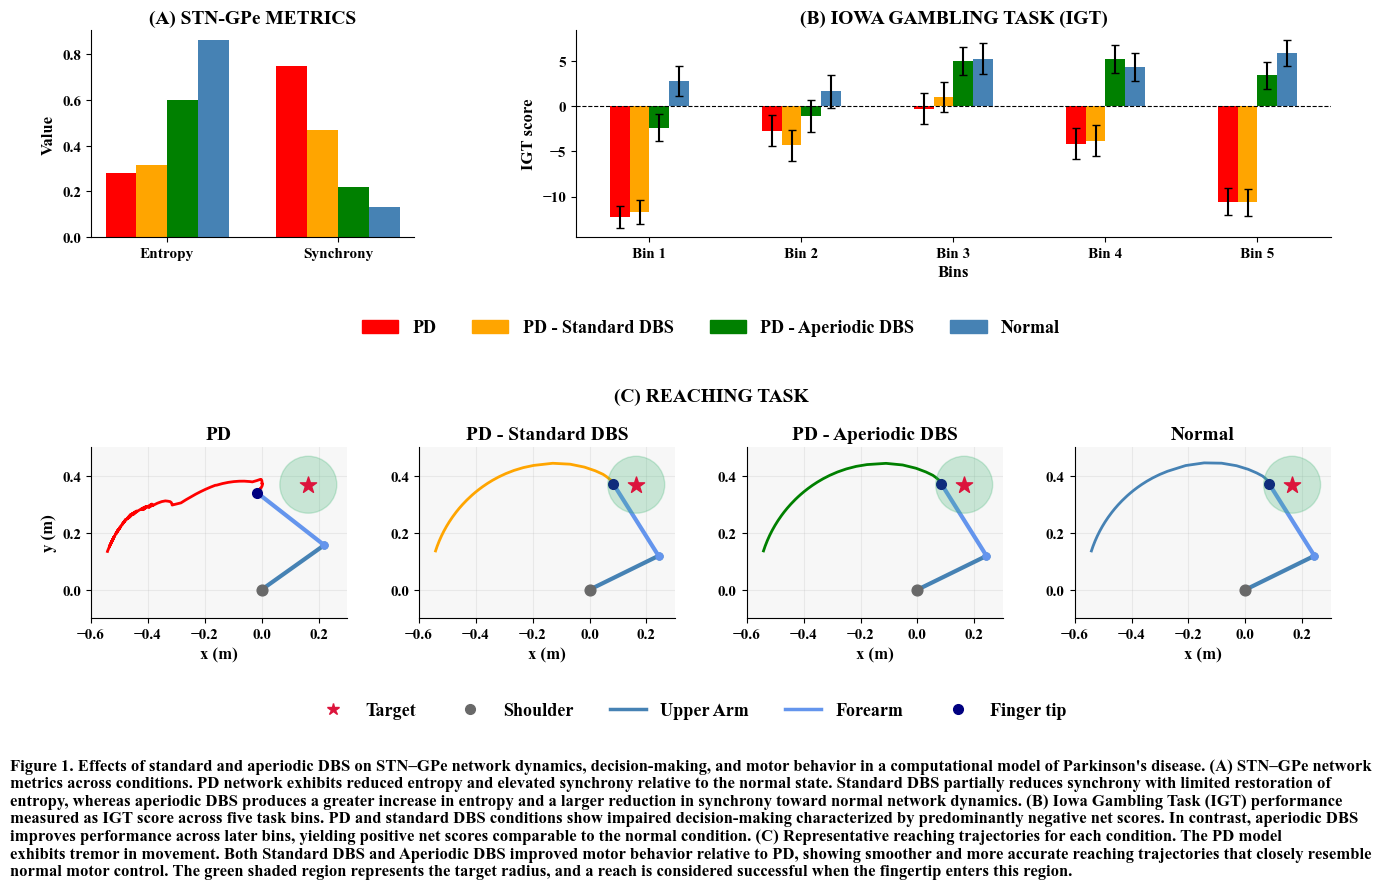

In [43]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
from matplotlib.lines import Line2D
import textwrap
# ── Font sizes ────────────────────────────────────────────────────────────────
TITLE_SIZE  = 14
LABEL_SIZE  = 12
TICK_SIZE   = 11
LEGEND_SIZE = 13

rcParams['font.family']      = 'Times New Roman'
rcParams['font.weight']      = 'bold'
rcParams['axes.titlesize']   = TITLE_SIZE
rcParams['axes.titleweight'] = 'bold'
rcParams['axes.labelsize']   = LABEL_SIZE
rcParams['axes.labelweight'] = 'bold'
rcParams['xtick.labelsize']  = TICK_SIZE
rcParams['ytick.labelsize']  = TICK_SIZE

# ── Colors & labels ───────────────────────────────────────────────────────────
COLORS = {
    'PD':          'red',
    'PD_std_DBS':  'orange',
    'PD_noisy_DBS':'green',
    'Normal':      'steelblue',
}
LABELS = {
    'PD':          'PD',
    'PD_std_DBS':  'PD - Standard DBS',
    'PD_noisy_DBS':'PD - Aperiodic DBS',
    'Normal':      'Normal',
}
CONDITIONS = ['PD', 'PD_std_DBS', 'PD_noisy_DBS', 'Normal']

TRAJ_FILES = {
    'PD':          'PD_traj_data.pkl',
    'PD_std_DBS':  'PD_std_DBS_traj_data.pkl',
    'PD_noisy_DBS':'PD_Noisy_DBS_traj_data.pkl',
    'Normal':      'Normal_traj_data.pkl',
}

# ── Data ──────────────────────────────────────────────────────────────────────
STN_GPE_entropy   = {'Normal':0.86,  'PD':0.279, 'PD_std_DBS':0.315, 'PD_noisy_DBS':0.6}
STN_GPE_synchrony = {'Normal':0.13,  'PD':0.75,  'PD_std_DBS':0.47,  'PD_noisy_DBS':0.22}

IGT = {
    'PD':          {'mean':[-12.28,-2.7,-0.28,-4.12,-10.58], 'std':[1.2, 1.72,1.72,1.77,1.5]},
    'PD_std_DBS':  {'mean':[-11.68,-4.32,1.06,-3.8,-10.64],  'std':[1.32,1.75,1.68,1.74,1.49]},
    'PD_noisy_DBS':{'mean':[-2.38,-1.04,5.04,5.30,3.44],     'std':[1.49,1.77,1.58,1.57,1.54]},
    'Normal':      {'mean':[2.8,1.7,5.32,4.38,5.92],         'std':[1.64,1.84,1.68,1.6,1.47]},
}

# ── Layout: 3-row outer grid — plots | legend strip | traj ───────────────────
fig = plt.figure(figsize=(16, 8))
outer = gridspec.GridSpec(3, 1, figure=fig,
                          height_ratios=[1, 0.08, 1.1],
                          hspace=0.55)

top_row  = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0],
                                            wspace=0.3, width_ratios=[0.3, 0.7])
traj_row = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec=outer[2], wspace=0.28)

# ─── (A) STN-GPe ──────────────────────────────────────────────────────────────
ax_stn = fig.add_subplot(top_row[0])
x, width = np.arange(2), 0.18

for i, cond in enumerate(CONDITIONS):
    vals = [STN_GPE_entropy[cond], STN_GPE_synchrony[cond]]
    ax_stn.bar(x + (i - 1.5)*width, vals, width,
               color=COLORS[cond], label=LABELS[cond])

ax_stn.set_xticks(x)
ax_stn.set_xticklabels(['Entropy', 'Synchrony'])
ax_stn.set_ylabel('Value')
ax_stn.set_title('(A) STN-GPe METRICS')
ax_stn.spines['top'].set_visible(False)
ax_stn.spines['right'].set_visible(False)

# ─── (B) IGT ──────────────────────────────────────────────────────────────────
ax_igt = fig.add_subplot(top_row[1])
x_igt  = np.arange(5) * 1.4

for i, cond in enumerate(CONDITIONS):
    ax_igt.bar(x_igt + (i - 1.5)*width,
               IGT[cond]['mean'], width,
               yerr=IGT[cond]['std'], capsize=3,
               color=COLORS[cond], label=LABELS[cond])

ax_igt.set_xticks(x_igt)
ax_igt.set_xticklabels([f'Bin {i}' for i in range(1, 6)])
ax_igt.set_xlabel('Bins')
ax_igt.set_ylabel('IGT score')
ax_igt.axhline(0, color='k', linestyle='--', linewidth=0.8)
ax_igt.set_title('(B) IOWA GAMBLING TASK (IGT)')
ax_igt.spines['top'].set_visible(False)
ax_igt.spines['right'].set_visible(False)

# ─── Condition legend — dedicated invisible axis in middle strip ───────────────
ax_leg = fig.add_subplot(outer[1])
ax_leg.set_axis_off()

cond_handles = [
    plt.Rectangle((0,0), 1, 1, color=COLORS[c], label=LABELS[c])
    for c in CONDITIONS
]
ax_leg.legend(
    handles=cond_handles,
    loc='center',
    ncol=4,
    frameon=False,
    prop={'family':'Times New Roman', 'weight':'bold', 'size':LEGEND_SIZE}
)

# ─── (C) Motor Reaching — invisible spanning axis for shared title ─────────────
ax_title = fig.add_subplot(outer[2])
ax_title.set_axis_off()
ax_title.set_title('(C) REACHING TASK', fontsize=TITLE_SIZE,
                   fontweight='bold', pad=12, y=1.01)

# ─── 4 trajectory subplots ────────────────────────────────────────────────────
for idx, cond in enumerate(CONDITIONS):
    ax = fig.add_subplot(traj_row[idx])

    with open(TRAJ_FILES[cond], 'rb') as f:
        d = pickle.load(f)

    X_t       = d['target']
    traj      = d['trajectory']
    shoulders = d['shoulders']
    elbows    = d['elbows']
    hands     = d['hands']
    fi        = len(traj) - 1

    ax.set_xlim(-0.6, 0.3)
    ax.set_ylim(-0.10, 0.5)
    ax.set_aspect('equal')
    ax.set_facecolor('#f7f7f7')
    ax.grid(alpha=0.2)

    ax.scatter(*X_t, s=150, color='crimson', marker='*', zorder=6)
    ax.scatter(0, 0,  s=60,  color='dimgray',            zorder=7)
    ax.plot(traj[:, 0], traj[:, 1], color=COLORS[cond], lw=2, alpha=1.0)
    ax.plot([shoulders[fi,0], elbows[fi,0]],
            [shoulders[fi,1], elbows[fi,1]],
            '-o', lw=3, ms=5, color='steelblue')
    ax.plot([elbows[fi,0], hands[fi,0]],
            [elbows[fi,1], hands[fi,1]],
            '-o', lw=3, ms=5, color='cornflowerblue')
    ax.plot(hands[fi,0], hands[fi,1], 'o', ms=7, color='navy')
    ax.add_patch(plt.Circle(X_t, radius=0.1, color='mediumseagreen', alpha=0.25, zorder=5))
    ax.set_title(LABELS[cond])
    ax.set_xlabel('x (m)')
    if idx == 0:
        ax.set_ylabel('y (m)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ─── Anatomy legend — second dedicated invisible axis below traj ───────────────
ax_leg2 = fig.add_axes([0.15, 0.01, 0.7, 0.04])   # [left, bottom, width, height]
ax_leg2.set_axis_off()

traj_handles = [
    Line2D([0],[0], color='crimson',       marker='*', linestyle='None', ms=9,  label='Target'),
    Line2D([0],[0], color='dimgray',        marker='o', linestyle='None', ms=7,  label='Shoulder'),
    Line2D([0],[0], color='steelblue',      lw=2.5,                             label='Upper Arm'),
    Line2D([0],[0], color='cornflowerblue', lw=2.5,                             label='Forearm'),
    Line2D([0],[0], color='navy',        marker='o', linestyle='None', ms=7,  label='Finger tip'),
]
ax_leg2.legend(
    handles=traj_handles,
    loc='center',
    ncol=5,
    frameon=False,
    prop={'family':'Times New Roman', 'weight':'bold', 'size':LEGEND_SIZE}
)

# ─── Figure caption ───────────────────────────────────────────────────────────
caption = (
    "Figure 1. Effects of standard and aperiodic DBS on STN–GPe network dynamics, decision-making, "
    "and motor behavior in a computational model of Parkinson's disease. "
    "(A) STN–GPe network metrics across conditions. PD network exhibits reduced entropy and elevated "
    "synchrony relative to the normal state. Standard DBS partially reduces synchrony with limited "
    "restoration of entropy, whereas aperiodic DBS produces a greater increase in entropy and a larger "
    "reduction in synchrony toward normal network dynamics. "
    "(B) Iowa Gambling Task (IGT) performance measured as IGT score across five task bins. PD and "
    "standard DBS conditions show impaired decision-making characterized by predominantly negative net "
    "scores. In contrast, aperiodic DBS improves performance across later bins, yielding positive net "
    "scores comparable to the normal condition. "
    "(C) Representative reaching trajectories for each condition. The PD model exhibits tremor in "
    "movement. Both Standard DBS and Aperiodic DBS improved motor behavior relative to PD, showing "
    "smoother and more accurate reaching trajectories that closely resemble normal motor control. "
    "The green shaded region represents the target radius, and a reach is considered successful when "
    "the fingertip enters this region."
)

wrapped_caption = "\n".join(textwrap.wrap(caption, width=185))

fig.text(
    0.5, -0.03,
    wrapped_caption,
    ha='center',
    va='top',
    fontsize=12,
    fontfamily='Times New Roman',
    # fontstyle='italic',
    fontweight='bold',
    transform=fig.transFigure,
    multialignment='left',
)
plt.savefig('combined_plot.png', dpi=300, bbox_inches='tight')
plt.show()